In [51]:
!pip install pandas numpy seaborn matplotlib scikit-learn xgboost shap

In [52]:
# ==============================================
# CELL 2: Import Libraries
# ==============================================
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

import xgboost as xgb
import shap

plt.style.use('ggplot')


In [53]:
# ==============================================
# CELL 3: Load Dataset (YOUR FILE PATH)
# ==============================================
df = pd.read_csv(r"E:\Primary Project Customer Churn Prediction\archive\WA_Fn-UseC_-Telco-Customer-Churn.csv")
print(f"Dataset shape: {df.shape}")
df.head()


Dataset shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [54]:
# ==============================================
# CELL 4: Basic Data Inspection & Cleaning
# ==============================================
df.info()
print("\nMissing values:")
print(df.isnull().sum())

# Convert TotalCharges from string to numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df = df.dropna() # Remove empty rows

# Drop customerID (unique ID, no predictive value)
df = df.drop("customerID", axis=1)

print(f"\nShape after cleaning: {df.shape}")
print("\nChurn class distribution:")
print(df["Churn"].value_counts())


<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

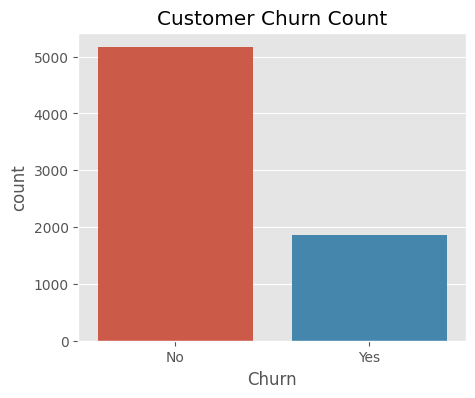

In [55]:
# ==============================================
# CELL 5: EDA - Target Churn Distribution Plot
# ==============================================
plt.figure(figsize=(5,4))
sns.countplot(x="Churn", data=df)
plt.title("Customer Churn Count")
plt.show()


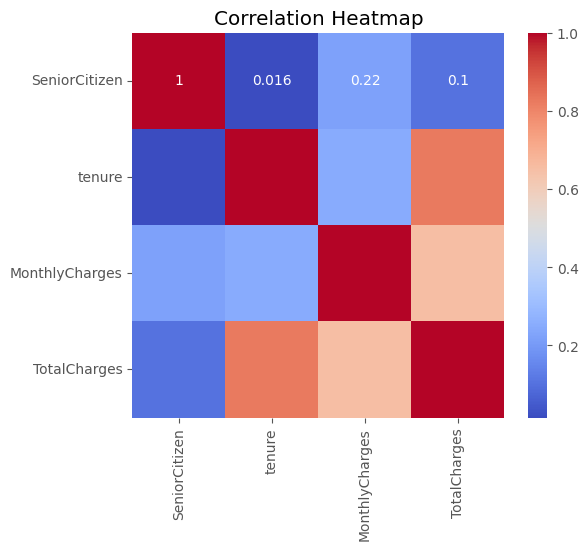

In [56]:
# ==============================================
# CELL 6: EDA - Correlation Heatmap (Numeric Features)
# ==============================================
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr = df[numeric_cols].corr()

plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


In [57]:
# ==============================================
# CELL 7: Train / Test Split
# ==============================================
# Split features and target
X = df.drop("Churn", axis=1)
y = df["Churn"]

# Encode target Yes/No → 1/0
le = LabelEncoder()
y = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")


Train set shape: (5625, 19)
Test set shape: (1407, 19)


In [58]:
# ==============================================
# Alternative: Class Weight for Imbalance (NO imblearn / SMOTE required)
# ==============================================
# Calculate scale_pos_weight for XGBoost
# scale_pos_weight = number of negative samples / number of positive samples
neg_samples = np.sum(y_train == 0)
pos_samples = np.sum(y_train == 1)
scale_pos_weight = neg_samples / pos_samples

print(f"Negative samples (No Churn): {neg_samples}")
print(f"Positive samples (Churn): {pos_samples}")
print(f"scale_pos_weight = {scale_pos_weight:.2f}")



Negative samples (No Churn): 4130
Positive samples (Churn): 1495
scale_pos_weight = 2.76


In [59]:
# ==============================================
# CELL 8: Preprocessing Pipeline Setup
# ==============================================
cat_cols = X.select_dtypes(include=["object"]).columns
num_cols = X.select_dtypes(include=[np.number]).columns

preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
], remainder="passthrough")


C:\Users\user\AppData\Local\Temp\ipykernel_7004\785562259.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include=["object"]).columns


In [60]:
# ==============================================
# CELL 9: Baseline Model - Logistic Regression
# ==============================================
log_pipe = Pipeline([
    ("preprocess", preprocessor),
    ("logreg", LogisticRegression(max_iter=1000))
])

log_pipe.fit(X_train, y_train)
y_pred_log = log_pipe.predict(X_test)
y_pred_proba_log = log_pipe.predict_proba(X_test)[:,1]

print("===== Logistic Regression Baseline =====")
print(classification_report(y_test, y_pred_log))
print(f"ROC AUC Score: {roc_auc_score(y_test, y_pred_proba_log):.3f}")


===== Logistic Regression Baseline =====
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.64      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407

ROC AUC Score: 0.836


C:\Users\user\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [61]:
# ==============================================
# CELL 10: Main Model - XGBoost Classifier
# ==============================================
xgb_pipe = Pipeline([
    ("preprocess", preprocessor),
    ("xgb", xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric="logloss"))
])

xgb_pipe.fit(X_train, y_train)
y_pred_xgb = xgb_pipe.predict(X_test)
y_pred_proba_xgb = xgb_pipe.predict_proba(X_test)[:,1]

print("===== XGBoost Classifier =====")
print(classification_report(y_test, y_pred_xgb))
print(f"ROC AUC Score: {roc_auc_score(y_test, y_pred_proba_xgb):.3f}")



===== XGBoost Classifier =====
              precision    recall  f1-score   support

           0       0.83      0.86      0.85      1033
           1       0.58      0.53      0.55       374

    accuracy                           0.77      1407
   macro avg       0.71      0.70      0.70      1407
weighted avg       0.77      0.77      0.77      1407

ROC AUC Score: 0.809


C:\Users\user\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [16:06:16] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [62]:
# Calculate scale_pos_weight
neg_samples = np.sum(y_train == 0)
pos_samples = np.sum(y_train == 1)
scale_pos_weight = neg_samples / pos_samples

print(f"Negative samples (No Churn): {neg_samples}")
print(f"Positive samples (Churn): {pos_samples}")
print(f"scale_pos_weight = {scale_pos_weight:.2f}")

# Build pipeline with weighted XGBoost
xgb_weighted_pipe = Pipeline([
    ("preprocess", preprocessor),
    ("xgb_weighted", xgb.XGBClassifier(
        random_state=42,
        use_label_encoder=False,
        eval_metric="logloss",
        scale_pos_weight = scale_pos_weight
    ))
])

xgb_weighted_pipe.fit(X_train, y_train)
y_pred_xgb_weighted = xgb_weighted_pipe.predict(X_test)
y_pred_proba_xgb_weighted = xgb_weighted_pipe.predict_proba(X_test)[:,1]

print("===== XGBoost with scale_pos_weight (Class Weight) =====")
print(classification_report(y_test, y_pred_xgb_weighted))
print(f"ROC AUC Score: {roc_auc_score(y_test, y_pred_proba_xgb_weighted):.3f}")


Negative samples (No Churn): 4130
Positive samples (Churn): 1495
scale_pos_weight = 2.76


C:\Users\user\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [16:06:16] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


===== XGBoost with scale_pos_weight (Class Weight) =====
              precision    recall  f1-score   support

           0       0.87      0.77      0.81      1033
           1       0.51      0.67      0.58       374

    accuracy                           0.74      1407
   macro avg       0.69      0.72      0.70      1407
weighted avg       0.77      0.74      0.75      1407

ROC AUC Score: 0.810


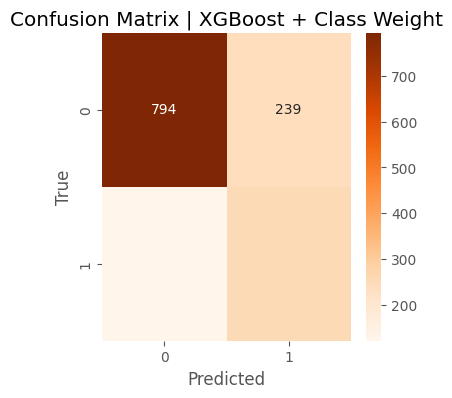

In [63]:
# ==============================================
# CELL 11: Confusion Matrix for XGBoost
# ==============================================
cm_weighted = confusion_matrix(y_test, y_pred_xgb_weighted)
plt.figure(figsize=(4,4))
sns.heatmap(cm_weighted, annot=True, fmt="d", cmap="Oranges")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix | XGBoost + Class Weight")
plt.show()


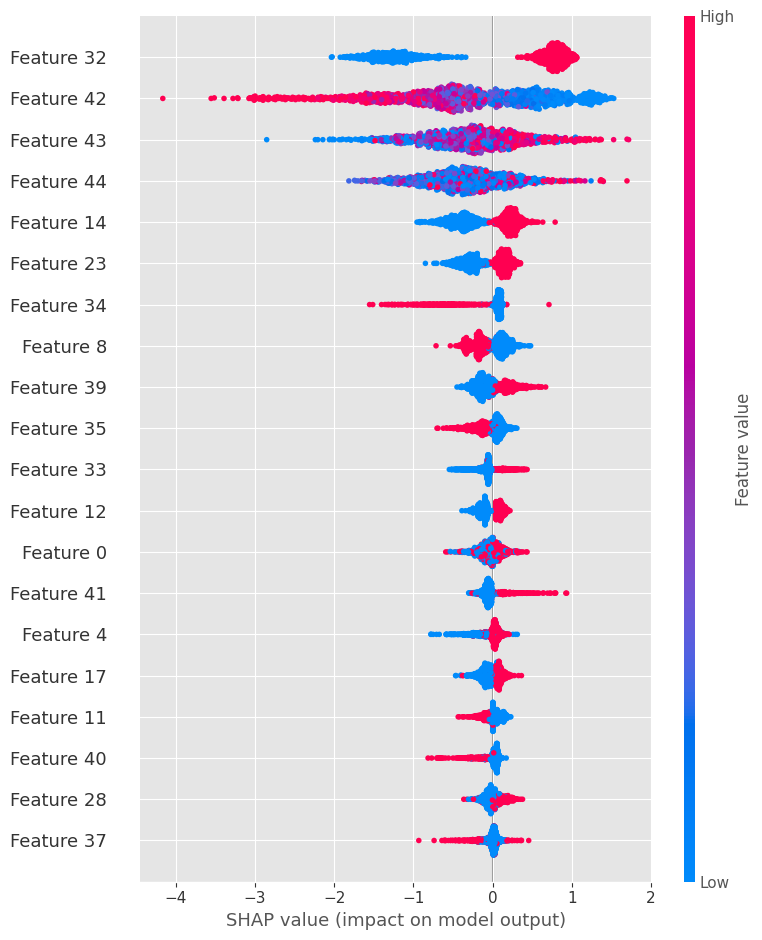

In [64]:
# ==============================================
# CELL 12: SHAP Explainability (Interview Highlight)
# ==============================================
preproc_w = xgb_weighted_pipe.named_steps["preprocess"]
xgb_model_w = xgb_weighted_pipe.named_steps["xgb_weighted"]
X_test_transformed_w = preproc_w.transform(X_test)

explainer_w = shap.TreeExplainer(xgb_model_w)
shap_values_w = explainer_w.shap_values(X_test_transformed_w)
shap.summary_plot(shap_values_w, X_test_transformed_w)



In [65]:
# ==============================================
# CELL 13: Inference Function - Predict New Customer
# ==============================================
def predict_churn_weighted(model, customer_data):
    df_cust = pd.DataFrame([customer_data])
    prob = model.predict_proba(df_cust)[:,1][0]
    pred = model.predict(df_cust)[0]
    return {"Churn Probability": round(prob,3), "Will Churn": bool(pred)}

new_customer = {
    "gender":"Male",
    "SeniorCitizen":0,
    "Partner":"No",
    "Dependents":"No",
    "tenure":12,
    "PhoneService":"Yes",
    "MultipleLines":"No",
    "InternetService":"Fiber optic",
    "OnlineSecurity":"No",
    "OnlineBackup":"Yes",
    "DeviceProtection":"No",
    "TechSupport":"No",
    "StreamingTV":"Yes",
    "StreamingMovies":"Yes",
    "Contract":"Month-to-month",
    "PaperlessBilling":"Yes",
    "PaymentMethod":"Electronic check",
    "MonthlyCharges":89.50,
    "TotalCharges":1045.20
}

print(predict_churn_weighted(xgb_weighted_pipe, new_customer))



{'Churn Probability': np.float32(0.843), 'Will Churn': True}


In [66]:
# ==============================================
# CELL 14: Hyperparameter Tuning (GridSearchCV)
# Optional upgrade — add this for stronger CV
# ==============================================
from sklearn.model_selection import GridSearchCV

param_grid = {
    "xgb__max_depth": [2,3,4],
    "xgb__learning_rate": [0.01, 0.1],
    "xgb__n_estimators": [50,100]
}

grid_search = GridSearchCV(
    estimator=xgb_pipe,
    param_grid=param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)
print("Best Parameters:", grid_search.best_params_)
print("Best Cross Validation ROC-AUC:", grid_search.best_score_)

# Test best tuned model
best_model = grid_search.best_estimator_
y_pred_tuned = best_model.predict(X_test)
y_pred_proba_tuned = best_model.predict_proba(X_test)[:,1]
print(f"\nTuned XGBoost Test ROC AUC: {roc_auc_score(y_test, y_pred_proba_tuned):.3f}")


Best Parameters: {'xgb__learning_rate': 0.1, 'xgb__max_depth': 4, 'xgb__n_estimators': 50}
Best Cross Validation ROC-AUC: 0.8481091127001223

Tuned XGBoost Test ROC AUC: 0.842


C:\Users\user\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [16:06:23] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
